In [1]:
# import pandas as pd

# # Load the labeled anomalies CSV
# df_anomalies = pd.read_csv('/home/david/david/code/telemanom/labeled_anomalies.csv')

# # Display first few rows
# # df_anomalies.head()

import pandas as pd

# Load labeled anomalies file
df_anomalies = pd.read_csv('/home/david/david/code/telemanom/labeled_anomalies.csv')

# Display unique telemetry channels
print(df_anomalies['chan_id'].unique())

# Check anomalies for a specific channel
df_anomalies[df_anomalies['chan_id'] == 'P-1']


['P-1' 'S-1' 'E-1' 'E-2' 'E-3' 'E-4' 'E-5' 'E-6' 'E-7' 'E-8' 'E-9' 'E-10'
 'E-11' 'E-12' 'E-13' 'A-1' 'D-1' 'P-2' 'P-3' 'D-2' 'D-3' 'D-4' 'A-2'
 'A-3' 'A-4' 'G-1' 'G-2' 'D-5' 'D-6' 'D-7' 'F-1' 'P-4' 'G-3' 'T-1' 'T-2'
 'D-8' 'D-9' 'F-2' 'G-4' 'T-3' 'D-11' 'D-12' 'B-1' 'G-6' 'G-7' 'P-7' 'R-1'
 'A-5' 'A-6' 'A-7' 'D-13' 'A-8' 'A-9' 'F-3' 'M-6' 'M-1' 'M-2' 'S-2' 'P-10'
 'T-4' 'T-5' 'F-7' 'M-3' 'M-4' 'M-5' 'P-15' 'C-1' 'C-2' 'T-12' 'T-13'
 'F-4' 'F-5' 'D-14' 'T-9' 'P-14' 'T-8' 'P-11' 'D-15' 'D-16' 'M-7' 'F-8']


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505


In [2]:
import numpy as np

# Load the telemetry data
data = np.load('/home/david/david/code/telemanom/data/test/P-1.npy')

# Check the shape of the data
print("Data Shape:", data.shape)

# Display the first 5 values
print("First 5 data points:\n", data[:5])


Data Shape: (8505, 25)
First 5 data points:
 [[-0.69516194  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.68570386  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.72571851  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.76136787  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0

In [3]:
# Here I check for data points or entries which are non-zero in the first place

import numpy as np

# Load the data
data = np.load('/home/david/david/code/telemanom/data/test/P-1.npy')

# Find columns with nonzero values
nonzero_columns = np.where(data.any(axis=0))[0]
print("Columns with nonzero values:", nonzero_columns)


Columns with nonzero values: [ 0  1  2  3  5  6  7  8  9 11 12 13 14 17 18 19 21 22]


In [4]:
# Now I gather the statistics of other nonzero entries/columns

import pandas as pd

# Convert to DataFrame for better readability
df = pd.DataFrame(data)

# Get summary statistics for only active columns
print(df.iloc[:, nonzero_columns].describe())


                0            1            2            3            5   \
count  8505.000000  8505.000000  8505.000000  8505.000000  8505.000000   
mean     -0.409049     0.036802     0.007055     0.028219     0.160729   
std       0.405683     0.188286     0.083700     0.165607     0.367302   
min      -1.000000     0.000000     0.000000     0.000000     0.000000   
25%      -0.712623     0.000000     0.000000     0.000000     0.000000   
50%      -0.560567     0.000000     0.000000     0.000000     0.000000   
75%      -0.168425     0.000000     0.000000     0.000000     0.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                6            7            8            9            11  \
count  8505.000000  8505.000000  8505.000000  8505.000000  8505.000000   
mean      0.125338     0.001411     0.000470     0.000705     0.001411   
std       0.331121     0.037538     0.021683     0.026553     0.037538   
min       0.000000     0.000000     0

In [5]:
import pandas as pd

df_labels = pd.read_csv("/home/david/david/code/telemanom/labeled_anomalies.csv")
print(df_labels.head())


  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  


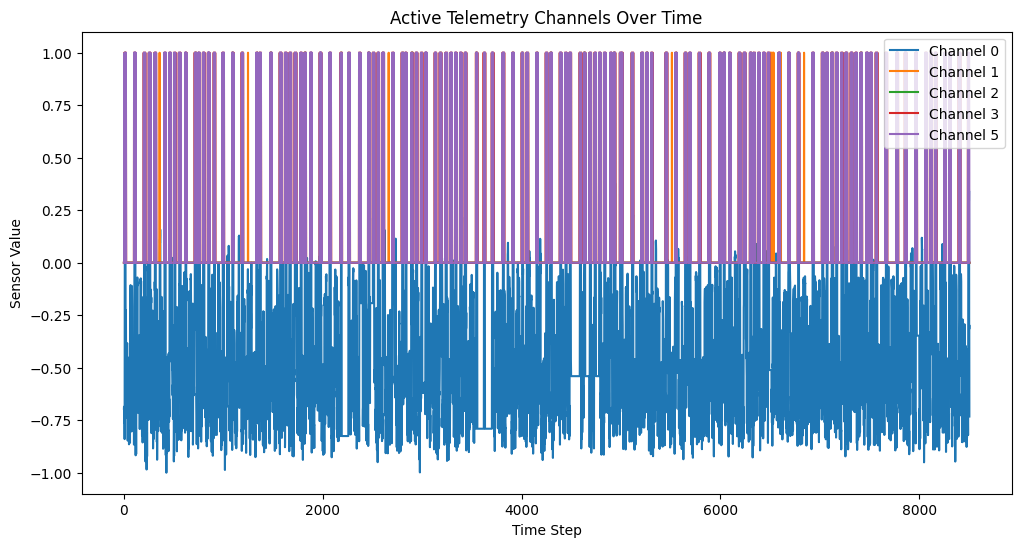

In [7]:
# This is my attempt to plot the values of only the first 5 sensors which have values i.e. non-zero to
# better understand the behaviour of sensors over time and see trends

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot selected nonzero columns
for col in nonzero_columns[:5]:  # Plot only the first 5 active channels
    plt.plot(data[:, col], label=f"Channel {col}")

plt.xlabel("Time Step")
plt.ylabel("Sensor Value")
plt.title("Active Telemetry Channels Over Time")
plt.legend()
plt.show()


In [8]:
# import os

# data_path = "/home/david/david/code/telemanom/data/"

# # List all available subdirectories and files
# for root, dirs, files in os.walk(data_path):
#     print(f"📂 Folder: {root}")
#     for file in files:
#         print(f"   📄 {file}")

import os

data_path = "/home/david/david/code/telemanom/data/"
print(os.listdir(data_path))

for item in os.listdir(data_path):
    print(item, "->", "Directory" if os.path.isdir(os.path.join(data_path, item)) else "File")

print(os.listdir(os.path.join(data_path, "train")))
print(os.listdir(os.path.join(data_path, "test")))

import numpy as np

file_path = os.path.join(data_path, "train", "M-4.npy")  # Example file
data = np.load(file_path)
print(data.shape)  # Check dimensions
print(data)  # Display sample data

print(os.listdir(os.path.join(data_path, "2018-05-19_15.00.10")))


['train', 'logs', '2018-05-19_15.00.10', 'test']
train -> Directory
logs -> Directory
2018-05-19_15.00.10 -> Directory
test -> Directory
['F-4.npy', 'P-15.npy', 'P-7.npy', 'P-11.npy', 'F-1.npy', 'D-14.npy', 'A-9.npy', 'T-10.npy', 'D-3.npy', 'P-1.npy', 'A-3.npy', 'T-4.npy', 'G-2.npy', 'M-3.npy', 'T-3.npy', 'M-6.npy', 'P-10.npy', 'D-7.npy', 'E-3.npy', 'M-2.npy', 'E-6.npy', 'E-8.npy', 'E-11.npy', 'G-1.npy', 'F-2.npy', 'T-2.npy', 'M-1.npy', 'D-6.npy', 'B-1.npy', 'E-9.npy', 'C-2.npy', 'E-12.npy', 'T-5.npy', 'F-3.npy', 'G-7.npy', 'D-16.npy', 'D-11.npy', 'A-8.npy', 'P-4.npy', 'G-4.npy', 'E-4.npy', 'D-13.npy', 'T-8.npy', 'E-5.npy', 'D-4.npy', 'A-6.npy', 'T-1.npy', 'S-2.npy', 'D-5.npy', 'E-2.npy', 'A-7.npy', 'D-8.npy', 'D-9.npy', 'D-2.npy', 'E-13.npy', 'E-1.npy', 'A-1.npy', 'D-15.npy', 'C-1.npy', 'D-1.npy', 'A-2.npy', 'G-6.npy', 'P-2.npy', 'D-12.npy', 'F-8.npy', 'A-4.npy', 'A-5.npy', 'G-3.npy', 'M-7.npy', 'M-4.npy', 'E-10.npy', 'T-9.npy', 'R-1.npy', 'P-14.npy', 'S-1.npy', 'F-7.npy', 'P-3.npy', 

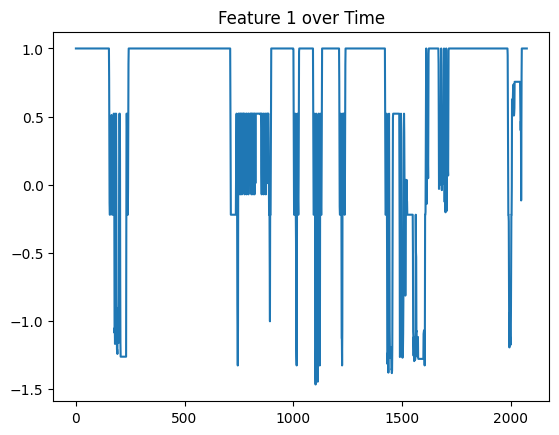

In [9]:
# I plot a few datapoints to check for anomalies

import matplotlib.pyplot as plt

plt.plot(data[:, 0])  # Example: Plot first column
plt.title("Feature 1 over Time")
plt.show()


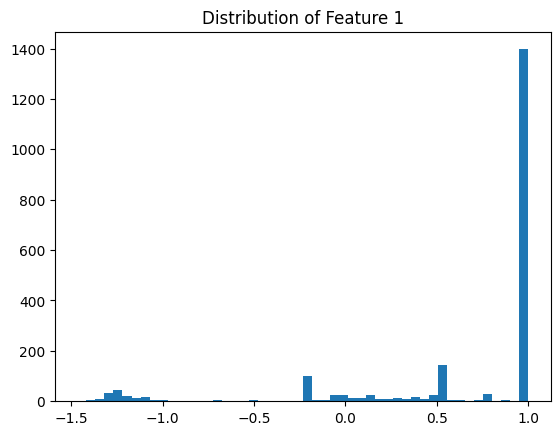

In [10]:
# Histogram analysis which would confirm if the data is categorical if there are only a few unique values

import numpy as np

plt.hist(data[:, 0], bins=50)
plt.title("Distribution of Feature 1")
plt.show()

#From the output I cannot tell exactly if the particular feature is categorical or not because although 
# there are dominant peaks and few unique values, there are also intermediate values and a sort of continuity which could indicate a 
# continuous feature with a sort of threshold instead of strictly categorical

In [11]:
# Because there are so many .npy files in y_hat, I'm carrying out the following steps to find the right file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

anomalies_path = "/home/david/david/code/telemanom/labeled_anomalies.csv"
anomalies_df = pd.read_csv(anomalies_path)
print(anomalies_df.head())


  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  


In [12]:
# I'm taking one of the metrics to look for anomalies and understand its nature
import ast  

# Converting string representation of list to actual list
channel = "P-1"
anomaly_data = anomalies_df[anomalies_df["chan_id"] == channel]

# Convert the string list of anomaly sequences into an actual list
anomaly_sequences = [ast.literal_eval(seq) for seq in anomaly_data["anomaly_sequences"].values]
# Print a nested list of anomaly index ranges
print(anomaly_sequences)  


[[[2149, 2349], [4536, 4844], [3539, 3779]]]


In [13]:
# Here I'm loading the actual and predicted data 
import matplotlib.pyplot as plt

data_actual = np.load("/home/david/david/code/telemanom/data/test/P-1.npy")  # Test/Actual data
y_hat = np.load("/home/david/david/code/telemanom/data/2018-05-19_15.00.10/y_hat/P-1.npy") #Predicted data

# Finding the difference between the actual and predicted values
print(f"data_actual shape: {data_actual.shape}, y_hat shape: {y_hat.shape}")


data_actual shape: (8505, 25), y_hat shape: (8245,)


In [14]:
# Since y_hat is a 1-D, I'm reshaping it to ensure it is a column vector

y_hat = y_hat.reshape(-1, 1)  # Converts (8245,) -> (8245, 1)

# Now to make the actual data and the y_hat data to be of the same length or rows, we can either
# 1. Trim the actual data(if first 8245 rows are relevant) 
# 2. Trim the y_hat data (if only first 8245 predictions matter)
# 3. Padd y_hat missing values with zero

# 1. data_actual = data_actual[:8245, :]
# 2. y_hat = y_hat[:8505]

# Here i'm implementing the 3rd one i.e. to padd y_hat

# 3.
y_hat = np.pad(y_hat, (0, 8505 - 8245), mode='constant', constant_values=0)

print(f"data_actual shape: {data_actual.shape}, y_hat shape: {y_hat.shape}")


data_actual shape: (8505, 25), y_hat shape: (8505, 261)


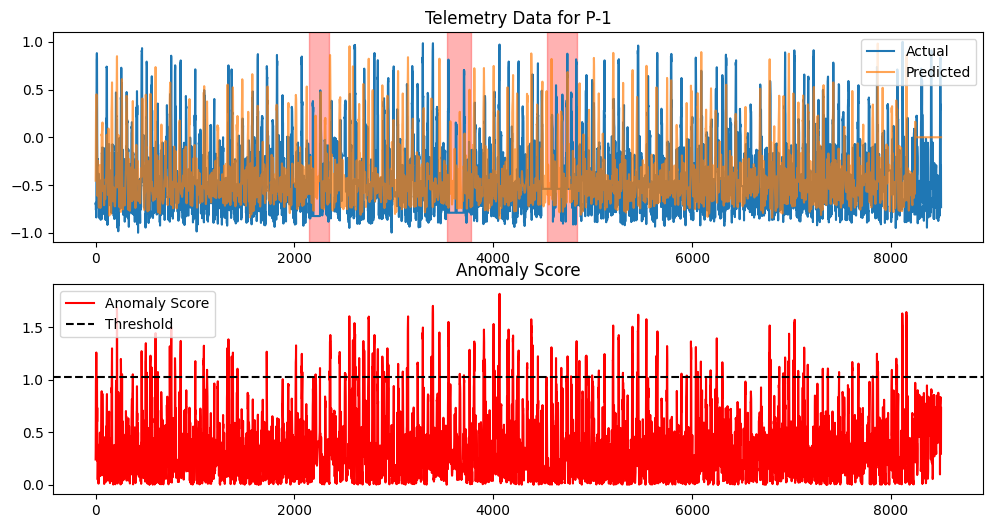

In [15]:
# Now that both the actual and predicted data have the same number of rows we can perform subtraction

# Computing the anomaly score

anomaly_score = np.abs(data_actual[:, 0] - y_hat[:, 0])  


# Visualise the results

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual vs predicted values
plt.subplot(2, 1, 1)
plt.plot(data_actual[:, 0], label="Actual")
plt.plot(y_hat[:, 0], label="Predicted", alpha=0.7)
plt.legend()
plt.title(f"Telemetry Data for {channel}")

# Highlight labeled anomalies
for seq in anomaly_sequences[0]:  # Since it's a nested list
    plt.axvspan(seq[0], seq[1], color="red", alpha=0.3, label="Labeled Anomaly")

# Plot anomaly score
plt.subplot(2, 1, 2)
plt.plot(anomaly_score, label="Anomaly Score", color="red")
plt.axhline(y=np.mean(anomaly_score) + 2 * np.std(anomaly_score), color="black", linestyle="--", label="Threshold")
plt.legend()
plt.title("Anomaly Score")

plt.show()


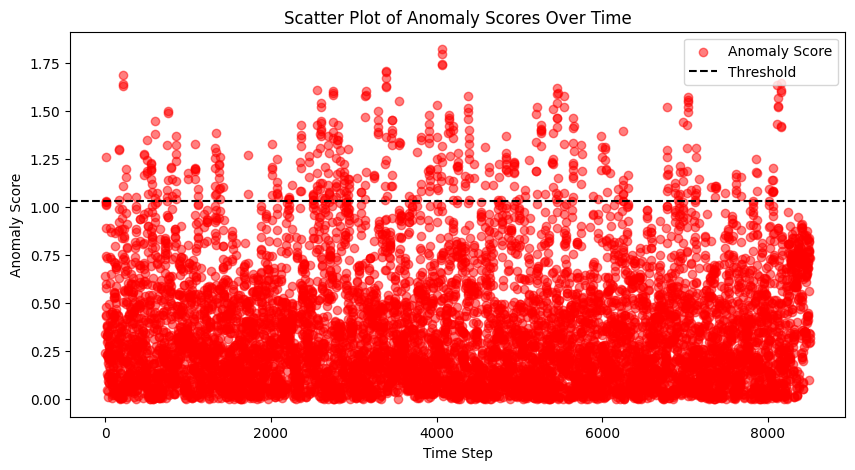

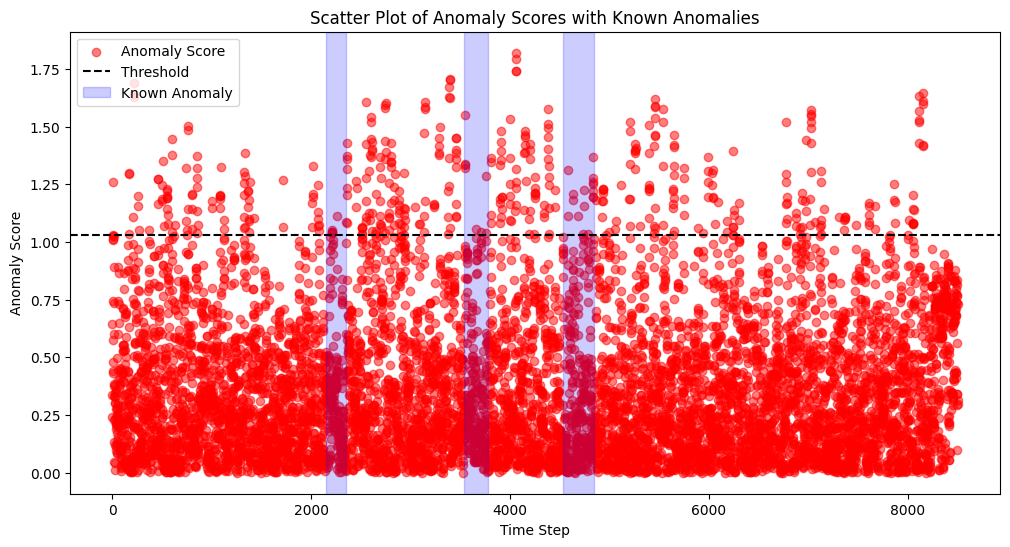

In [16]:
# I think a scatter plot would enhance the understanding and inferences that we can derive from the data
# Primarily I have two possible ideas
# 1. Anomaly Score vs. Time
# 2. Actual vs. Predicted for only Anomalous points

# 1. 
import numpy as np
import matplotlib.pyplot as plt

threshold = np.mean(anomaly_score) + 2 * np.std(anomaly_score)  # Threshold based on mean + 2*std

plt.figure(figsize=(10,5))
plt.scatter(range(len(anomaly_score)), anomaly_score, c='red', alpha=0.5, label="Anomaly Score")
plt.axhline(y=threshold, color='black', linestyle='dashed', label="Threshold")  # Now threshold is defined
plt.xlabel("Time Step")
plt.ylabel("Anomaly Score")
plt.legend()
plt.title("Scatter Plot of Anomaly Scores Over Time")
plt.show()

# Trying to overlay with the known anomalies

# Assuming known anomaly sequences are stored in a list
known_anomalies = [[2149, 2349], [4536, 4844], [3539, 3779]]  # Example for P-1

plt.figure(figsize=(12, 6))

# Scatter plot for anomaly scores
plt.scatter(range(len(anomaly_score)), anomaly_score, c='red', alpha=0.5, label="Anomaly Score")
plt.axhline(y=threshold, color='black', linestyle='dashed', label="Threshold")

# Highlight known anomaly regions
for start, end in known_anomalies:
    plt.axvspan(start, end, color='blue', alpha=0.2, label="Known Anomaly" if start == known_anomalies[0][0] else "")

plt.xlabel("Time Step")
plt.ylabel("Anomaly Score")
plt.title("Scatter Plot of Anomaly Scores with Known Anomalies")
plt.legend()
plt.show()


In [17]:
# Checking if the anomalies align with the known anomaly sequences

# Identifies missed anomalies (false negatives)
#  Finds false positives

# Convert detected anomalies to a set for fast lookup
detected_anomalies = set(np.where(anomaly_score > threshold)[0])

# Check how many detected anomalies fall inside the known sequences
matched = 0
missed = 0
false_positives = 0

for start, end in known_anomalies:
    detected_in_range = [idx for idx in detected_anomalies if start <= idx <= end]
    matched += len(detected_in_range)
    missed += (end - start + 1) - len(detected_in_range)

false_positives = len(detected_anomalies) - matched

print(f"Matched Anomalies: {matched}")
print(f"Missed Known Anomalies: {missed}")
print(f"False Positives: {false_positives}")



Matched Anomalies: 29
Missed Known Anomalies: 722
False Positives: 442


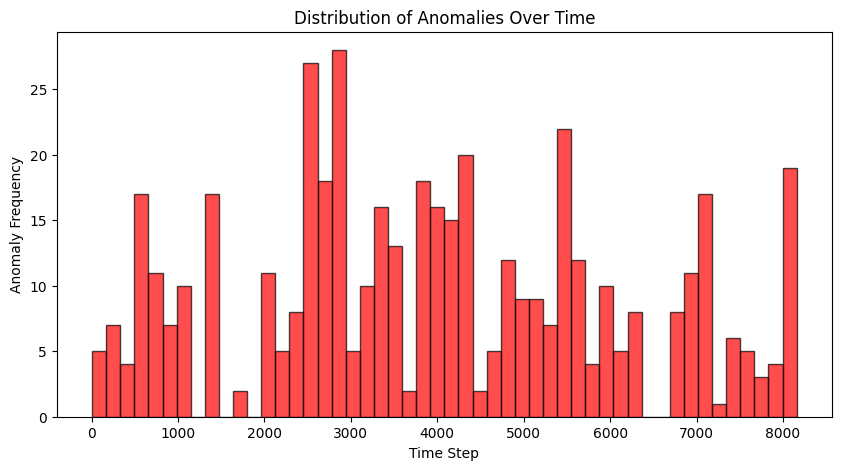

In [18]:
# Checking if the anomalies are clustered or random
# Because if they are clustered, it could indicate a systemic issue

# Plot a histogram of anomaly occurrence
plt.figure(figsize=(10, 5))
plt.hist(np.where(anomaly_score > threshold)[0], bins=50, color='red', alpha=0.7, edgecolor='black')
plt.xlabel("Time Step")
plt.ylabel("Anomaly Frequency")
plt.title("Distribution of Anomalies Over Time")
plt.show()


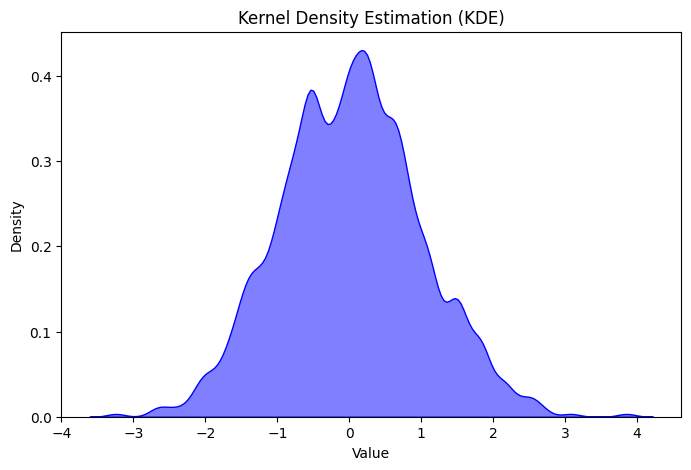

In [20]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate some synthetic data (replace with your anomaly scores)
np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=1000)  # Normal distribution
# I've kept the smoothness(bw_adjust) as 0.5. Decreasing would give rise to more peaks and incresing 
# would make the graph more smoother

# Plot KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(data, fill=True, color="blue", alpha=0.5, bw_adjust=0.5)  # Adjust smoothness with `bw_adjust`
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Kernel Density Estimation (KDE)")
plt.show()


In [21]:
# Now I'm going back to the zero columns to analyse them

# Identifying the zero columns

import numpy as np
import pandas as pd

# Load your .npy file
npy_file = "/home/david/david/code/telemanom/data/test/P-1.npy"
data = np.load(npy_file)

# Convert to DataFrame for easier analysis
df = pd.DataFrame(data)

# Find columns with all zeros
zero_columns = df.columns[(df == 0).all()]

print(f"Total Zero Columns: {len(zero_columns)}")
print("Zero Columns Index:", zero_columns.tolist())


Total Zero Columns: 7
Zero Columns Index: [4, 10, 15, 16, 20, 23, 24]


In [22]:
# Checking the percentage of zeros in each column because if some columns have zeros and not all, 
# then we can check their percentage

zero_percentage = (df == 0).sum() / len(df) * 100
print(zero_percentage)


0       0.000000
1      96.319812
2      99.294533
3      97.178131
4     100.000000
5      83.927102
6      87.466196
7      99.858907
8      99.952969
9      99.929453
10    100.000000
11     99.858907
12     99.952969
13     99.917695
14     99.917695
15    100.000000
16    100.000000
17     97.154615
18     97.154615
19     98.577307
20    100.000000
21     95.767196
22     95.990594
23    100.000000
24    100.000000
dtype: float64


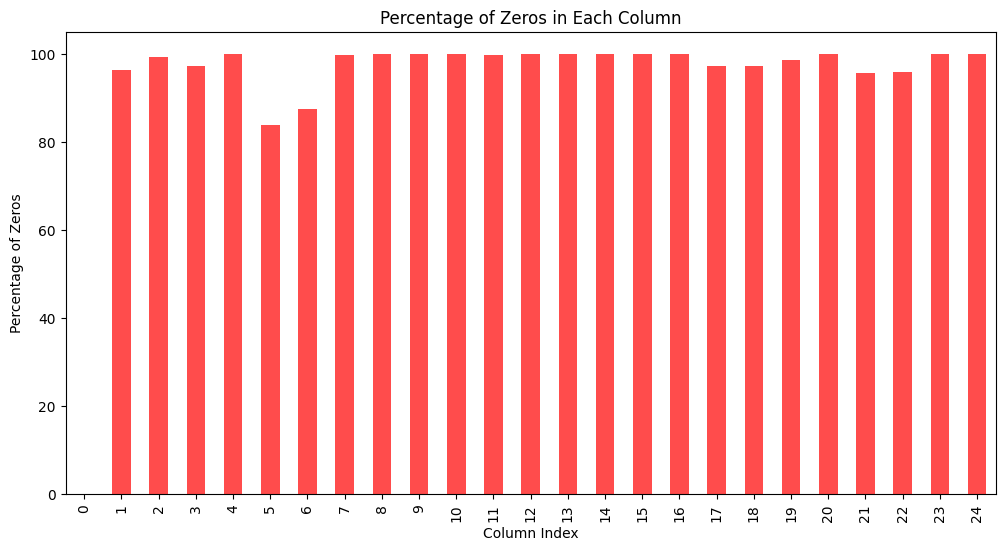

In [23]:
# Visualising the zeero percentage

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
zero_percentage.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Column Index")
plt.ylabel("Percentage of Zeros")
plt.title("Percentage of Zeros in Each Column")
plt.show()

In [24]:
# Now I'm trying to find out if the zero columns align with the anomaly values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File Paths
npy_file = "/home/david/david/code/telemanom/data/test/P-1.npy"
csv_file = "/home/david/david/code/telemanom/labeled_anomalies.csv"

# Load test data
data = np.load(npy_file)
df = pd.DataFrame(data)

# Load anomaly labels CSV
df_labels = pd.read_csv(csv_file)

# Check Data
print("Test Data Shape:", df.shape)
print("Anomaly Labels Shape:", df_labels.shape)

Test Data Shape: (8505, 25)
Anomaly Labels Shape: (82, 5)


In [25]:
# Now that I know the above, I'm now checking how many sensor columns contain only zeros throughout all
# the timestamps

zero_columns = df.columns[(df == 0).all()]
print(f"Total Zero Columns: {len(zero_columns)}")
print("Zero Columns Index:", zero_columns.tolist())


Total Zero Columns: 7
Zero Columns Index: [4, 10, 15, 16, 20, 23, 24]


In [26]:
# Before deciding what to do on the 7 zero columns, I'm checking if any of the zero columns match with
# anomaly labels

# Convert anomaly labels to a set for quick lookup
anomalous_channels = set(df_labels["chan_id"].unique())  # Assuming "chan_id" refers to sensor indices

zero_columns_set = set(zero_columns)

# Find intersection (zero columns that also have anomalies)
affected_sensors = zero_columns_set.intersection(anomalous_channels)

print("Zero Columns with Anomalies:", affected_sensors)


Zero Columns with Anomalies: set()


From the above output I understood that since there are no zero columns with anomalies, or none of the zero columns correspond to the anomaly-affected sensors, we can drop these columns. The reason for them being zero could be 
1. a sensor malfunction or they must have never been active during the data collection
2. could indicate a Feature Engineering issue that is the sensors must not have been useful for this mission and never used
3. If these columns were meant to contain values, the dataset might be incomplete or require preprocessing 

In [27]:
# Drop zero columns from the dataset
df_data_cleaned = df.drop(columns=zero_columns)

# Print new shape
print("New Data Shape after dropping zero columns:", df_data_cleaned.shape)


New Data Shape after dropping zero columns: (8505, 18)
